In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
#from geopy.geocoders import Nominatim
import time


In [ ]:
#pip install folium requests

Note: you may need to restart the kernel to use updated packages.


In [12]:
df_maestro = pd.read_csv('https://media.githubusercontent.com/media/clararodriguezacevedo/descriptiva-real-estate/refs/heads/main/data/raw/dataframe_maestro.tsv', sep='\t')

In [13]:
df_maestro.shape

(66180, 21)

In [14]:
df = df_maestro.copy()

# Análisis Inicial

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66180 entries, 0 to 66179
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fecha_Scraping     66180 non-null  object 
 1   Posting_ID         66180 non-null  int64  
 2   Sito               66180 non-null  object 
 3   Operación          66180 non-null  object 
 4   Precio             66180 non-null  object 
 5   Expensas           45549 non-null  object 
 6   Calle              60722 non-null  object 
 7   Altura             60722 non-null  float64
 8   Piso               15167 non-null  object 
 9   Barrio             66180 non-null  object 
 10  Detalles           65957 non-null  object 
 11  Descripción        65868 non-null  object 
 12  Link               66180 non-null  object 
 13  Amenities          66180 non-null  int64  
 14  Losa_Central       66180 non-null  int64  
 15  Aire_Acond         66180 non-null  int64  
 16  Apto_Credito       661

In [6]:
df.columns

Index(['Fecha_Scraping', 'Posting_ID', 'Sito', 'Operación', 'Precio',
       'Expensas', 'Calle', 'Altura', 'Piso', 'Barrio', 'Detalles',
       'Descripción', 'Link', 'Amenities', 'Losa_Central', 'Aire_Acond',
       'Apto_Credito', 'Cochera', 'Seguridad', 'Luminoso',
       'Balcon_Aterrazado'],
      dtype='object')

In [50]:
df.describe()

,Posting_ID,Altura,Amenities,Losa_Central,Aire_Acond,Apto_Credito,Cochera,Seguridad,Luminoso,Balcon_Aterrazado
count,6.618000e+04,60722.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000
mean,3.692180e+07,2255.691726,1.272635,0.097749,0.316893,0.072983,0.288697,0.213796,0.601224,0.091674
std,2.008695e+07,1714.396910,1.714579,0.296977,0.465269,0.260110,0.453160,0.409987,0.489650,0.288568
min,1.527159e+06,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.863395e+07,950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.938779e+07,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,5.842992e+07,3100.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,5.882838e+07,54300.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Normalizamos los nombres de las columnas

In [16]:
df = df.rename(columns={"Sito": "sitio","Operación": "operacion"})

In [17]:
df.columns = (df.columns.str.lower())

Revisamos las filas duplicadas y eliminamos los registros idénticos

In [18]:
#verifico si hay duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 3243


In [19]:
df = df.drop_duplicates(keep = 'first').reset_index(drop=True)

In [20]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 0


In [21]:
df.isnull().sum()

fecha_scraping           0
posting_id               0
sitio                    0
operacion                0
precio                   0
expensas             19838
calle                 5370
altura                5370
piso                 49314
barrio                   0
detalles               220
descripción            293
link                     0
amenities                0
losa_central             0
aire_acond               0
apto_credito             0
cochera                  0
seguridad                0
luminoso                 0
balcon_aterrazado        0
dtype: int64

In [22]:
df['piso'].value_counts(dropna=False)

piso
NaN     49314
1        2117
2        1866
3        1416
4        1229
        ...  
EC          1
1y2         1
5370        1
34          1
pa          1
Name: count, Length: 123, dtype: int64

In [64]:
df['barrio'].value_counts(dropna=False)   

barrio
Palermo                           6433
Recoleta                          5549
Belgrano                          4544
Caballito                         3322
Villa Urquiza                     2374
                                  ... 
Otro                                 3
Barrio Parque General Belgrano       3
Concepción                           3
Los Perales                          1
Barrio Justo Suarez                  1
Name: count, Length: 106, dtype: int64

Arreglamos las columnas de los precios, identificando la moneda utilizada. Asumimos que los precios que leen 'USD' son los que están en dólares, y los que no los que estan en Pesos. 

In [23]:
df['moneda'] = df['precio'].apply(lambda x: 'usd' if 'usd' in str(x).lower() else 'ars')

In [24]:
df['precio'] = (df['precio'].astype(str).str.lower().str.replace('usd', '', regex=False).str.replace('ars', '', regex=False).str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())
df['precio'] = df["precio"].apply(lambda x: float(x) if x != 'consultar' else np.nan)

Las expensas están siempre expresadas en pesos

In [25]:
df['expensas'] = (df['expensas'].str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())
df['expensas'] = df["expensas"].apply(lambda x: float(x) if x != '' else np.nan)

In [26]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda 

count          mean    median           std  \
moneda operacion                                                        
ars    alquiler           14458  8.282753e+05  700000.0  9.965850e+05   
       alquiler_temporal    810  7.122810e+05  750000.0  3.849273e+05   
       venta                 47  6.357208e+06  200000.0  2.414848e+07   
usd    alquiler            6879  5.346962e+03    1200.0  5.369935e+04   
       alquiler_temporal   6065  5.744404e+03     850.0  2.247339e+05   
       venta              33184  2.428972e+05  148000.0  3.647445e+05   

                              min          max  
moneda operacion                                
ars    alquiler               1.0  111111111.0  
       alquiler_temporal      1.0    2800000.0  
       venta              50000.0  150000000.0  
usd    alquiler               1.0    1850000.0  
       alquiler_temporal      5.0   12322222.0  
       venta                  1.0   12000000.0

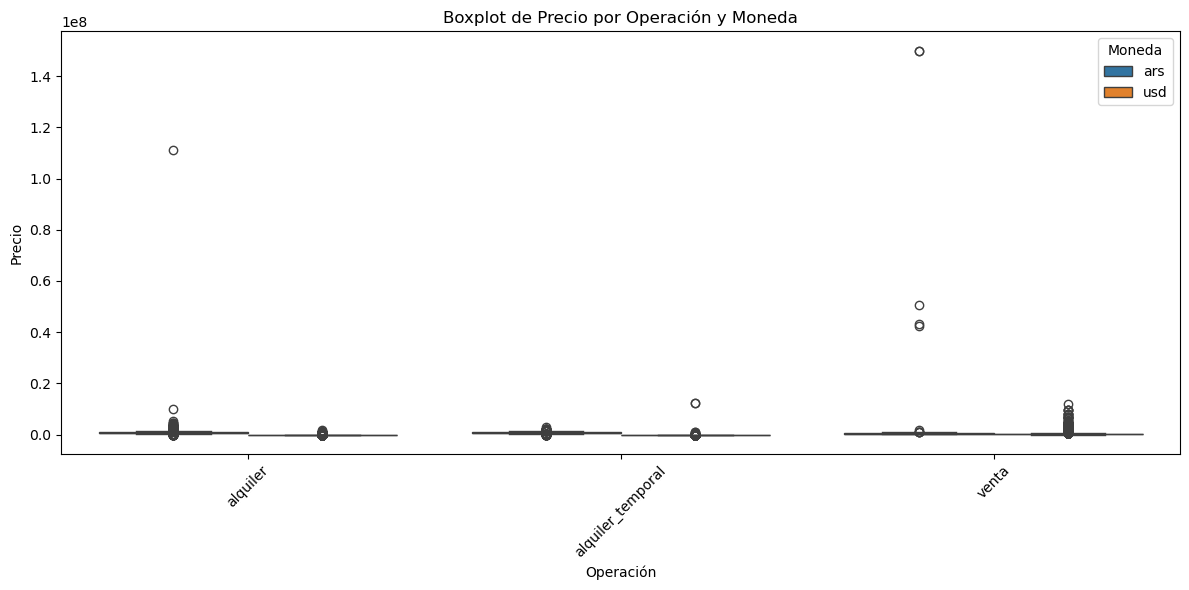

In [106]:
df_plot = df.dropna(subset=["precio", "moneda", "operacion"]).copy()
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x="operacion", y="precio", hue="moneda")
plt.title("Boxplot de Precio por Operación y Moneda")
plt.xlabel("Operación")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.legend(title="Moneda")
plt.tight_layout()
plt.show()

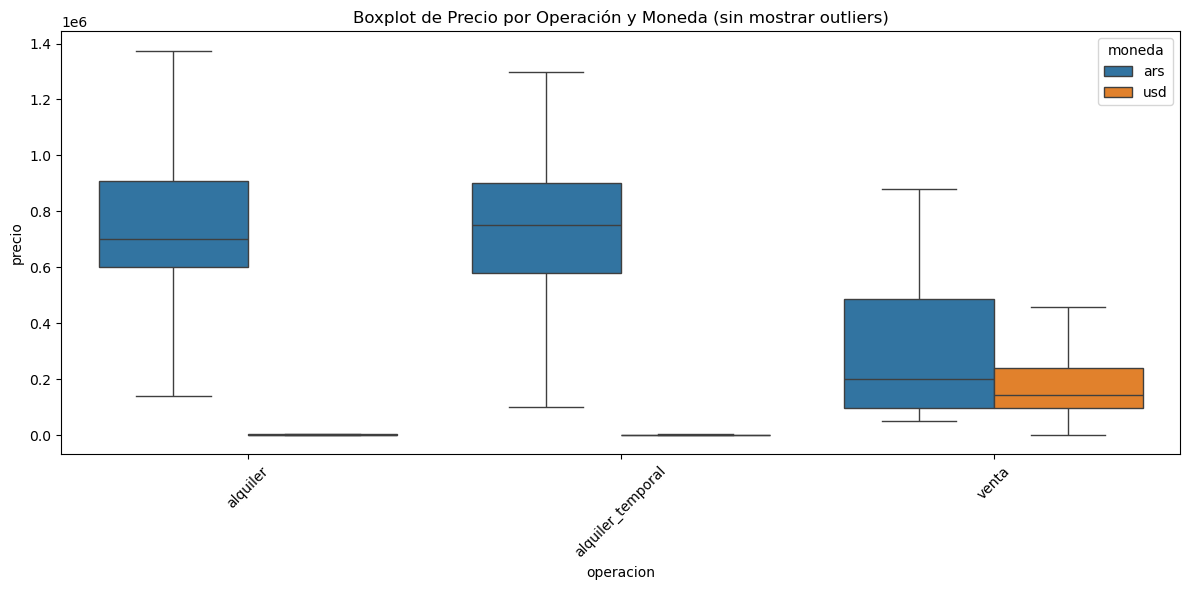

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x="operacion", y="precio", hue="moneda", showfliers=False)
plt.title("Boxplot de Precio por Operación y Moneda (sin mostrar outliers)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

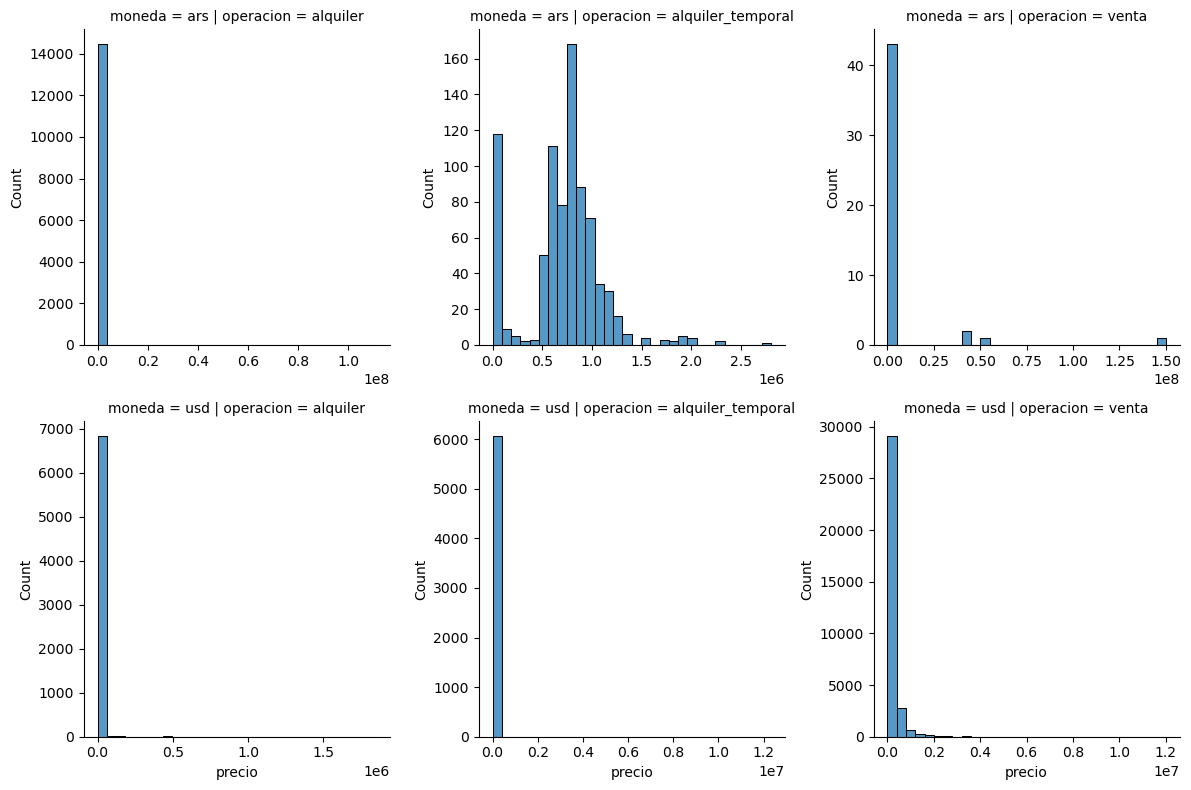

In [67]:
df_precio = df.dropna(subset=["precio", "moneda", "operacion"]).copy()

g = sns.FacetGrid(df_precio, row="moneda", col="operacion", sharex=False, sharey=False, height=4)
g.map(sns.histplot, "precio", bins=30)
plt.show()

Las escalas para los tipos de monedas y tipos de operaciones son diferentes. Por eso, para analizar a los outliers, vamos a separar la base en los distintos casos. También vamos a analizar los outliers según el tipo de moneda ya que los mercados en pesos Argentinos y en Dólares son distintos. 

Para poder graficar un mapa con las propiedades por barrio, primero debemos normalizar los títulos de los barrios

In [27]:
mapeo = {
    "Palermo Nuevo": "Palermo",
    "Palermo Viejo": "Palermo",
    "Palermo Hollywood": "Palermo",
    "Palermo Soho": "Palermo",
    "Palermo Chico": "Palermo",
    "Las Cañitas": "Palermo",
    "Botanico": "Palermo",
    "Botánico": "Palermo",

    "Belgrano R": "Belgrano",
    "Belgrano C": "Belgrano",
    "Belgrano Chico": "Belgrano",
    "Belgrano Barrancas": "Belgrano",
    "Barrio Chino": "Belgrano",

    "Almagro Norte": "Almagro",
    "Almagro Sur": "Almagro",
    "Abasto": "Almagro",

    "Caballito Norte": "Caballito",
    "Caballito Sur": "Caballito",
    "Parque Rivadavia": "Caballito",
    "Primera Junta": "Caballito",
    "Cid Campeador": "Caballito",

    "Flores Norte": "Flores",
    "Flores Sur": "Flores",

    "Floresta Norte": "Floresta",
    "Floresta Sur": "Floresta",

    "Centro": "San Nicolas",
    "Microcentro": "San Nicolas",
    "Centro / Microcentro": "San Nicolas",
    "San Nicolás": "San Nicolas",
    "Tribunales": "San Nicolas",
    "Congreso": "San Nicolas",

    "Núñez": "Nuñez",
    "Lomas De Núñez": "Nuñez",
    "Lomas De Nuñez": "Nuñez",
    "River": "Nuñez",

    "Constitución": "Constitucion",
    "Concepción": "San Cristobal",
    "Once": "Balvanera",
    "Pompeya": "Nueva Pompeya",

    "Barrio Norte": "Recoleta",
    "Plaza San Martín": "Retiro",
    "Catalinas": "Retiro",
    "Puerto Retiro": "Retiro",

    "Parque Centenario": "Caballito",
    "Parque Las Heras": "Palermo",

    "Urquiza R": "Villa Urquiza",

    "Villa Pueyrredón": "Villa Pueyrredon",
    "Villa General Mitre": 'Villa Gral. Mitre',
    "La Paternal": "La Paternal",
    "Los Perales": "Mataderos",
    "Agronomía": "Agronomia",

    "Boca": "La Boca",

    "Barrio Norte": "Recoleta",
    "Barrio Parque Saavedra": "Saavedra",
    "Barrio Parque General Belgrano": "Belgrano",
    "Barrio San Pedro": "Saavedra",
    "Barrio Justo Suarez": "Villa Urquiza",
    "Barrio Naón": "Agronomia",
    "Naón": "Agronomia",
    "Barrio Parque": "Palermo",
    "Distrito Quartier": "Puerto Madero",

    "Otro": None, 
}

In [28]:
import folium
import requests
#utilizamos el geojason de la ciudad de bueos aires
url_geojson = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson"
geojson_barrios = requests.get(url_geojson).json()

nombres_geojson = {f["properties"]["nombre"] for f in geojson_barrios["features"]}

df["barrio_norm"] = df["barrio"].str.strip().str.title()
df["barrio_oficial"] = df["barrio_norm"].replace(mapeo)

df_filtrado = df[df["barrio_oficial"].isin(nombres_geojson)]
conteo = df_filtrado.groupby("barrio_oficial").size().reset_index(name="cantidad")

nombres_geojson = {f["properties"]["nombre"] for f in geojson_barrios["features"]}
nombres_df = set(conteo["barrio_oficial"])
print("Sin match:", nombres_df - nombres_geojson)

Sin match: set()


In [29]:
mapa = folium.Map(location=[-34.6037, -58.3816], zoom_start=12, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=geojson_barrios,
    data=conteo,
    columns=["barrio_oficial", "cantidad"],
    key_on="feature.properties.nombre",   
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_caption="Cantidad de propiedades",
    nan_fill_color="lightgray",
).add_to(mapa)

folium.GeoJson(
    geojson_barrios,
    style_function=lambda x: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.GeoJsonTooltip(
        fields=["nombre"],            
        aliases=["Barrio:"],
    )
).add_to(mapa)

mapa.save("mapa_barrios.html")
print("✓ Listo")

✓ Listo


Como se puede ver en el mapa, los barrios de Palermo, Belgrano, Recoleta y Caballito son los más representados en las bases de datos.

In [54]:
# Ver qué tiene conteo para ese barrio
print(conteo[conteo["barrio_oficial"].str.contains("Mitre", case=False)])

# Comparar caracter por caracter
nombre_df  = "Villa General Mitre"
nombre_geo = [n for n in nombres_geojson if "mitre" in n.lower()][0]

print(f"En df:     '{nombre_df}' — bytes: {nombre_df.encode()}")
print(f"En GeoJSON:'{nombre_geo}' — bytes: {nombre_geo.encode()}")

Empty DataFrame
Columns: [barrio_oficial, cantidad]
Index: []
En df:     'Villa General Mitre' — bytes: b'Villa General Mitre'
En GeoJSON:'Villa Gral. Mitre' — bytes: b'Villa Gral. Mitre'


In [58]:
tabla_barrio_operacion = (
    df.groupby(["barrio_oficial", "operacion"])
      .size()
      .unstack(fill_value=0)
)

tabla_barrio_operacion["Total_barrio"] = tabla_barrio_operacion.sum(axis=1)
tabla_barrio_operacion.loc["Total_operacion"] = tabla_barrio_operacion.sum(axis=0)

tabla_barrio_operacion

operacion,alquiler,alquiler_temporal,venta,Total_barrio
barrio_oficial,,,,
Agronomia,30,1,92,123
Almagro,805,412,1446,2663
Balvanera,621,195,1156,1972
Barracas,220,15,488,723
Belgrano,1812,604,3322,5738
Boedo,175,15,352,542
Caballito,1500,239,2567,4306
Chacarita,122,41,203,366
Coghlan,96,26,311,433


La cantidad mínima de propiedades de los barrios se encuentra en Villa Riachuelo, con 5 propiedades. Asimismo, la operación con la menor cantidad de propiedades disponibles es 'alquiler_temporal'. Por ende, esperamos que las conclusiones más robustas del análisis sean sobre los barrios con mayor cantidad de propiedades (como los mencionados previamente), pero esperamos obtener conclusiones fuertes sobre los tres tipos de operaciones ya que 'alquiler_temporal' siendo la columna con la menor cantidad de filas presenta más de 8000 de las mismas.

# Reconocimiento de outliers

In [25]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda 

count          mean    median           std  \
moneda operacion                                                        
ars    alquiler           14458  8.282753e+05  700000.0  9.965850e+05   
       alquiler_temporal    810  7.122810e+05  750000.0  3.849273e+05   
       venta                 47  6.357208e+06  200000.0  2.414848e+07   
usd    alquiler            6879  5.346962e+03    1200.0  5.369935e+04   
       alquiler_temporal   6065  5.744404e+03     850.0  2.247339e+05   
       venta              33184  2.428972e+05  148000.0  3.647445e+05   

                              min          max  
moneda operacion                                
ars    alquiler               1.0  111111111.0  
       alquiler_temporal      1.0    2800000.0  
       venta              50000.0  150000000.0  
usd    alquiler               1.0    1850000.0  
       alquiler_temporal      5.0   12322222.0  
       venta                  1.0   12000000.0

Las escalas para los tipos de monedas y tipos de operaciones son diferentes. Por eso, para analizar a los outliers, vamos a separar la base en los distintos casos. También vamos a analizar los outliers según el tipo de moneda ya que los mercados en pesos Argentinos y en Dólares son distintos. 

In [110]:
df_venta_usd = df[(df["moneda"] == "usd") & (df["operacion"] == "venta")].copy() #Ignoramos las ventas en pesos porque son muy pocos registros (47)
df_alquiler_usd = df[(df["moneda"] == "usd") & (df["operacion"] == "alquiler")].copy()
df_alquiler_ars = df[(df["moneda"] == "ars") & (df["operacion"] == "alquiler")].copy()
df_alquilertemp_usd = df[(df["moneda"] == "usd") & (df["operacion"] == "alquiler_temporal")].copy()
df_alquilertemp_ars = df[(df["moneda"] == "ars") & (df["operacion"] == "alquiler_temporal")].copy()


Utilizamos jarque berra para analizar normalidad

In [111]:
from scipy.stats import jarque_bera

dfs = {
    "df_venta_usd": df_venta_usd,
    "df_alquiler_usd": df_alquiler_usd,
    "df_alquiler_ars": df_alquiler_ars,
    "df_alquilertemp_usd": df_alquilertemp_usd,
    "df_alquilertemp_ars": df_alquilertemp_ars
}

for nombre, df_temp in dfs.items():
    serie = df_temp["precio"].dropna()

    print(f"\n--- {nombre} ---")
    print(f"n = {len(serie)}")

    if len(serie) < 3:
        print("No hay suficientes datos para aplicar Jarque-Bera.")
        continue

    stat, p = jarque_bera(serie)

    print(f"Estadístico Jarque-Bera: {stat:.4f}")
    print(f"p-valor: {p:.4f}")


--- df_venta_usd ---
n = 33184
Estadístico Jarque-Bera: 36543339.4858
p-valor: 0.0000

--- df_alquiler_usd ---
n = 6879
Estadístico Jarque-Bera: 53165062.8381
p-valor: 0.0000

--- df_alquiler_ars ---
n = 14458
Estadístico Jarque-Bera: 64819572963.9497
p-valor: 0.0000

--- df_alquilertemp_usd ---
n = 6065
Estadístico Jarque-Bera: 2236590470.3299
p-valor: 0.0000

--- df_alquilertemp_ars ---
n = 810
Estadístico Jarque-Bera: 162.4827
p-valor: 0.0000


Como el p valor es pequeño, rechazamos normalidad. Verificamos que ninguna columna de precio tenga valores menores a 0 antes de aplicar Box-Cox.

In [33]:
for nombre, df_temp in dfs.items():
    print(f"{nombre}: {(df_temp['precio'] <= 0).sum()}")

df_venta_usd: 0
df_alquiler_usd: 0
df_alquiler_ars: 0
df_alquilertemp_usd: 0
df_alquilertemp_ars: 0


Aplicamos Box Cox y luego utilizamos Tukey para detectar los outliers

In [112]:
from scipy.stats import boxcox

def tukey_outliers(series):
    serie_valida = series.dropna()
    q1 = np.percentile(serie_valida, 25)
    q3 = np.percentile(serie_valida, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

lambdas = {}
        
for nombre, df_temp in dfs.items():
    print(f"\n{nombre}")
    
    mask_validos = df_temp["precio"].notna() & (df_temp["precio"] > 0)
    
    if mask_validos.sum() < 2:
        print("No hay suficientes valores válidos")
        continue
      
    data_bc, lambda_bc = boxcox(df_temp.loc[mask_validos, "precio"])
    lambdas[nombre] = lambda_bc
    df_temp["boxcox"] = np.nan
    df_temp.loc[mask_validos, "boxcox"] = data_bc
    
    df_temp["outlier_boxcox"] = tukey_outliers(df_temp["boxcox"])
    
    n_outliers = df_temp["outlier_boxcox"].sum()
    print(f"Outliers: {n_outliers}")
    print(f"Porcentaje: {n_outliers / mask_validos.sum() * 100:.2f}%")  # sobre válidos, no total




df_venta_usd
Outliers: 767
Porcentaje: 2.31%

df_alquiler_usd
Outliers: 79
Porcentaje: 1.15%

df_alquiler_ars
Outliers: 731
Porcentaje: 5.06%

df_alquilertemp_usd
Outliers: 156
Porcentaje: 2.57%

df_alquilertemp_ars
Outliers: 147
Porcentaje: 18.15%


Como podemos ver, en general hay un porcentaje bajo de outliers a través de cada combinación operación-moneda. Por ende, vamos a realizar imputación mediante Winsor (reemplazar mediante el límite superior o inferior) para mantener la distribución de los datos. 

De todas formas, no vamos a aplicarle este procedimiento a los alquileres temporarios en ARS, ya que este presenta una cantidad más alta de outliers (18%)

In [113]:
dfs2 = {
    "df_venta_usd": df_venta_usd,
    "df_alquiler_usd": df_alquiler_usd,
    "df_alquiler_ars": df_alquiler_ars,
    "df_alquilertemp_usd": df_alquilertemp_usd
}

from scipy.special import inv_boxcox

for nombre, df_temp in dfs2.items():
    mask_validos = df_temp["boxcox"].notna()
    serie_bc = df_temp.loc[mask_validos, "boxcox"]
    
    q1 = np.percentile(serie_bc, 25)
    q3 = np.percentile(serie_bc, 75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    
    # Copiamos precio original
    df_temp["precio_imputado"] = df_temp["precio"].copy()
    
    # Solo tocamos las filas donde outlier_boxcox == True
    mask_outlier = df_temp["outlier_boxcox"] == True
    
    boxcox_clippeado = df_temp.loc[mask_outlier, "boxcox"].clip(lower=lim_inf, upper=lim_sup)
    df_temp.loc[mask_outlier, "precio_imputado"] = inv_boxcox(boxcox_clippeado, lambdas[nombre])
    
    print(f"{nombre}: {mask_outlier.sum()} outliers imputados")
    print(f"  precio original (outliers):   {df_temp.loc[mask_outlier, 'precio'].values[:5]}")
    print(f"  precio imputado (outliers):   {df_temp.loc[mask_outlier, 'precio_imputado'].values[:5]}\n")

df_venta_usd: 767 outliers imputados
  precio original (outliers):   [4500000. 2100000. 1445900. 3500000. 2147000.]
  precio imputado (outliers):   [1138385.41245073 1138385.41245073 1138385.41245073 1138385.41245073
 1138385.41245073]

df_alquiler_usd: 79 outliers imputados
  precio original (outliers):   [20000. 20000. 15000. 13500. 13000.]
  precio imputado (outliers):   [12870.17890862 12870.17890862 12870.17890862 12870.17890862
 12870.17890862]

df_alquiler_ars: 731 outliers imputados
  precio original (outliers):   [1700000. 3500000. 1890000. 1900000. 2000000.]
  precio imputado (outliers):   [1581848.97334623 1581848.97334623 1581848.97334623 1581848.97334623
 1581848.97334623]

df_alquilertemp_usd: 156 outliers imputados
  precio original (outliers):   [3800. 4000. 8000. 5000. 4000.]
  precio imputado (outliers):   [3704.93813204 3704.93813204 3704.93813204 3704.93813204 3704.93813204]



In [ ]:
#Hay q definir q hariamos con los outliers de df_alquilertemp_ars y dsp concatenar los ultimos dfs con los precios imputados


...

# Parse variables detalles y descripcion:

In [40]:
detalles = df['detalles'].unique()
print(detalles)

['60 m² tot. 2 amb. 1 dorm. 1 baño'
 '114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.'
 '121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.' ...
 '111 m² cubie. 2 dorm. 2 baños' '90 m² cubie. 3 dorm. 27 años'
 '99 m² cubie. 2 dorm. 95 años']


## Funciones

In [109]:
import pandas as pd
import re

def parse_detalles(s):
    """Parsea la columna 'detalles' de ZonaProp/ArgEnProp en columnas individuales."""
    if pd.isna(s):
        return {}
    result = {}

    # Superficie total (ej: "60 m² tot." o "60 m² cubie.")
    m_tot = re.search(r'([\d,\.]+)\s*m²\s*tot\.?', s)
    m_cub = re.search(r'([\d,\.]+)\s*m²\s*cubie\.?', s)
    if m_tot:
        result['m2_total'] = float(m_tot.group(1).replace(',', '.'))
    elif m_cub:
        result['m2_total'] = float(m_cub.group(1).replace(',', '.'))

    # Ambientes (ej: "3 amb." o "3 ambientes")
    amb = re.search(r'(\d+)\s*amb\.', s)
    ambientes = re.search(r'(\d+)\s*ambientes', s)
    if amb:
        result['ambientes'] = int(amb.group(1))
    elif ambientes:
        result['ambientes'] = int(ambientes.group(1))

    # Dormitorios (ej: "2 dorm.")
    dorm = re.search(r'(\d+)\s*dorm\.', s)
    if dorm:
        result['dormitorios'] = int(dorm.group(1))

    # Baños (ej: "1 baño" o "2 baños")
    ban = re.search(r'(\d+)\s*baños?', s)
    if ban:
        result['baños'] = int(ban.group(1))
        
    # Antigüedad: 0 si "A estrenar", número si "X años"
    a_estrenar = re.search(r'A\s*[Ee]strenar', s)
    anios = re.search(r'(\d+)\s*años', s)
    if a_estrenar:
        result['antiguedad_años'] = 0
    elif anios:
        result['antiguedad_años'] = int(anios.group(1))

    return result

In [110]:
def parse_descripcion(s):
    if pd.isna(s):
        return {}
    
    s_low = s.lower()
    result = {}

    # --- Superficie (completar si no viene de detalles) ---
    m_tot = re.search(r'([\d,\.]+)\s*m²?\s*tot\.?', s)
    m_cub = re.search(r'([\d,\.]+)\s*m²?\s*cubi', s)
    if m_tot:
        result['m2_total'] = float(m_tot.group(1).replace(',', '.'))
    elif m_cub:
        result['m2_total'] = float(m_cub.group(1).replace(',', '.'))

    # --- Ambientes ---
    amb = re.search(r'(\d+)\s*amb(?:ientes?|\.)', s_low)
    if amb:
        result['ambientes'] = int(amb.group(1))

    # --- Dormitorios ---
    dorm = re.search(r'(\d+)\s*(?:dormitorio|habitaci[oó]n|dorm\.)', s_low)
    if dorm:
        result['dormitorios'] = int(dorm.group(1))

    # --- Baños ---
    ban = re.search(r'(\d+)\s*ba[ñn]os?', s_low)
    if ban:
        result['baños'] = int(ban.group(1))

    # --- Antigüedad ---
    if re.search(r'a estrenar|entrega inmediata|en construccion|en pozo', s_low):
        result['antiguedad_años'] = 0
    else:
        anios = re.search(r'(\d+)\s*años', s_low)
        if anios:
            result['antiguedad_años'] = int(anios.group(1))

    # --- Orientación ---
    if re.search(r'contra\s*frente|contrafrente', s_low):
        result['orientacion'] = 'Contra Frente'
    elif re.search(r'\bfrente\b', s_low):
        result['orientacion'] = 'Frente'
    elif re.search(r'\blateral\b', s_low):
        result['orientacion'] = 'Lateral'

    # --- Vista ---
    if re.search(r'vista\s*al?\s*r[ií]o', s_low):
        result['vista_rio'] = True
    if re.search(r'vista\s*al?\s*park|vista\s*verde|vista\s*jard[ií]n', s_low):
        result['vista_verde'] = True

    # --- Balcón ---
    if re.search(r'balc[oó]n', s_low):
        result['balcon'] = True

    # --- Terraza ---
    if re.search(r'terraza', s_low):
        result['terraza'] = True

    # --- Pileta ---
    if re.search(r'pileta|piscina', s_low):
        result['pileta'] = True

    # --- Parrilla ---
    if re.search(r'parrill[ao]', s_low):
        result['parrilla'] = True

    # --- SUM ---
    if re.search(r'\bsum\b|sal[oó]n\s*de\s*usos\s*m[uú]ltiples', s_low):
        result['sum'] = True

    # --- Laundry / Lavadero ---
    if re.search(r'laundry|lavadero', s_low):
        result['lavadero'] = True

    # --- Gimnasio ---
    if re.search(r'gimnasio|gym\b', s_low):
        result['gimnasio'] = True

    # --- Baulera ---
    if re.search(r'baulera', s_low):
        result['baulera'] = True

    # --- Calefacción ---
    if re.search(r'piso\s*radiante', s_low):
        result['calefaccion'] = 'Piso radiante'
    elif re.search(r'radiadores?', s_low):
        result['calefaccion'] = 'Radiadores'
    elif re.search(r'calefacci[oó]n\s*central', s_low):
        result['calefaccion'] = 'Central'
    elif re.search(r'calefacci[oó]n', s_low):
        result['calefaccion'] = 'Sí'

    # --- Agua caliente central ---
    if re.search(r'agua\s*caliente\s*central', s_low):
        result['agua_caliente_central'] = True

    # --- Ascensor ---
    if re.search(r'sin\s*ascensor|no\s*tiene\s*ascensor', s_low):
        result['ascensor'] = False
    elif re.search(r'ascensor', s_low):
        result['ascensor'] = True

    # --- Portero ---
    if re.search(r'portero\s*(?:el[eé]ctrico|visor|virtual)', s_low):
        result['portero'] = True


    # --- Apto profesional ---
    if re.search(r'no\s*apto\s*prof', s_low):
        result['apto_profesional'] = False
    elif re.search(r'apto\s*prof|apto\s*para\s*prof', s_low):
        result['apto_profesional'] = True

    # --- Mascotas ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:mascotas?|animales?)|no\s*mascotas?', s_low):
        result['permite_mascotas'] = False
    elif re.search(r'acept[ao]\s*mascotas?|permite?\s*mascotas?|mascotas?\s*(?:ok|permitidas?)', s_low):
        result['permite_mascotas'] = True

    # --- Garantías ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = False
    elif re.search(r'(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = True
    if re.search(r'finaer', s_low):
        result['acepta_finaer'] = True

    # --- Financiación ---
    if re.search(r'financiaci[oó]n|financia\b', s_low):
        result['ofrece_financiacion'] = True

    # --- Accesibilidad ---
    if re.search(r'movilidad\s*reducida|accesible\s*para\s*personas', s_low):
        result['accesible_movilidad_reducida'] = True

    # --- Dependencia de servicio ---
    if re.search(r'dependencia\s*(?:de\s*)?servicio', s_low):
        result['dependencia_servicio'] = True

    # --- Cocina tipo ---
    if re.search(r'cocina\s*american[ao]|cocina\s*integrada|cocina\s*abierta', s_low):
        result['cocina_tipo'] = 'Americana/Integrada'
    elif re.search(r'cocina\s*independiente|cocina\s*separada', s_low):
        result['cocina_tipo'] = 'Independiente'

    return result


## Implementamos las funciones:

In [111]:
df_det = pd.DataFrame(df['detalles'].apply(parse_detalles).tolist())

In [112]:
df_desc = pd.DataFrame(df['descripción'].apply(parse_descripcion).tolist())

In [113]:
# Detalles pisa a descripcion (detalles es más confiable)
combined = df_desc.combine_first(df_det)

In [114]:
bool_cols = [
    'balcon', 'terraza', 'pileta', 'parrilla', 'sum', 'lavadero', 'gimnasio',
    'baulera', 'aire_acondicionado', 'agua_caliente_central', 'ascensor',
    'portero', 'seguridad_24hs', 'apto_profesional', 'permite_mascotas',
    'acepta_caucion', 'acepta_finaer', 'ofrece_financiacion',
    'accesible_movilidad_reducida', 'dependencia_servicio',
    'vista_rio', 'vista_verde', 'monoambiente'
]

for col in bool_cols:
    if col in combined.columns:
        combined[col] = combined[col].map({True: 1, False: 0}).fillna(0).astype(int)

In [116]:
combined.head(10)

,accesible_movilidad_reducida,acepta_caucion,acepta_finaer,agua_caliente_central,ambientes,antiguedad_años,apto_profesional,ascensor,balcon,baulera,...,ofrece_financiacion,orientacion,parrilla,permite_mascotas,pileta,portero,sum,terraza,vista_rio,vista_verde
0,0,0,0,0,2.0,NaN,0,0,1,0,...,0,NaN,0,0,0,0,0,1,0,0
1,0,1,0,0,3.0,NaN,0,0,1,0,...,0,Contra Frente,1,0,0,0,0,1,0,0
2,0,0,0,0,4.0,NaN,0,0,1,0,...,0,NaN,1,0,1,0,0,0,0,0
3,0,0,0,0,2.0,2.0,1,0,1,0,...,0,Frente,0,0,0,0,0,1,0,0
4,0,0,0,0,3.0,NaN,0,0,0,0,...,0,NaN,0,0,1,0,0,0,0,0
5,0,0,0,1,1.0,NaN,0,0,0,0,...,0,NaN,1,0,0,0,0,0,0,0
6,0,0,0,0,2.0,NaN,0,0,0,0,...,0,NaN,0,0,0,0,0,0,0,0
7,0,0,0,0,4.0,NaN,0,0,0,0,...,0,Frente,0,0,0,0,0,0,0,0
8,0,0,0,0,2.0,NaN,0,0,1,0,...,0,Frente,1,0,1,0,0,0,0,0
9,0,0,0,1,1.0,NaN,1,0,1,0,...,0,Frente,0,0,0,0,0,0,0,0


Agrego las nuevas variables al df:

In [119]:
df_final = pd.concat([df, combined], axis=1)
df_final.head()

,fecha_scraping,posting_id,sitio,operacion,precio,expensas,calle,altura,piso,barrio,...,ofrece_financiacion,orientacion,parrilla,permite_mascotas,pileta,portero,sum,terraza,vista_rio,vista_verde
0,2026-04-12,58757240,zonaprop,alquiler,750000.0,300000.0,Mansilla,2936.0,NaN,Barrio Norte,...,0,NaN,0,0,0,0,0,1,0,0
1,2026-04-12,58818211,zonaprop,alquiler,1700000.0,400000.0,Cespedes,2300.0,NaN,Belgrano,...,0,Contra Frente,1,0,0,0,0,1,0,0
2,2026-04-12,58564550,zonaprop,alquiler,2500.0,1150000.0,Riobamba,1200.0,NaN,Recoleta,...,0,NaN,1,0,1,0,0,0,0,0
3,2026-04-12,58314210,zonaprop,alquiler,1300.0,NaN,Pereyra Lucena,2500.0,NaN,Palermo,...,0,Frente,0,0,0,0,0,1,0,0
4,2026-04-12,58810878,zonaprop,alquiler,3800.0,NaN,Lola Mora,400.0,NaN,Puerto Madero,...,0,NaN,0,0,1,0,0,0,0,0
